In [10]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [11]:
train_df = pd.read_csv("train_labels.csv")
test_df = pd.read_csv("test_labels.csv")

# initial data

print(f"Train Samples: {len(train_df)}")
print(f"Test Samples: {len(test_df)}")
print(f"Train Label Distribution: {train_df['label'].value_counts().get(0,0) / len(train_df):.2f}")
print(f"Test Label Distribution: {test_df['label'].value_counts().get(0,0) / len(test_df):.2f}")

Train Samples: 373
Test Samples: 78
Train Label Distribution: 0.33
Test Label Distribution: 0.36


In [12]:
import matplotlib.pyplot as plt

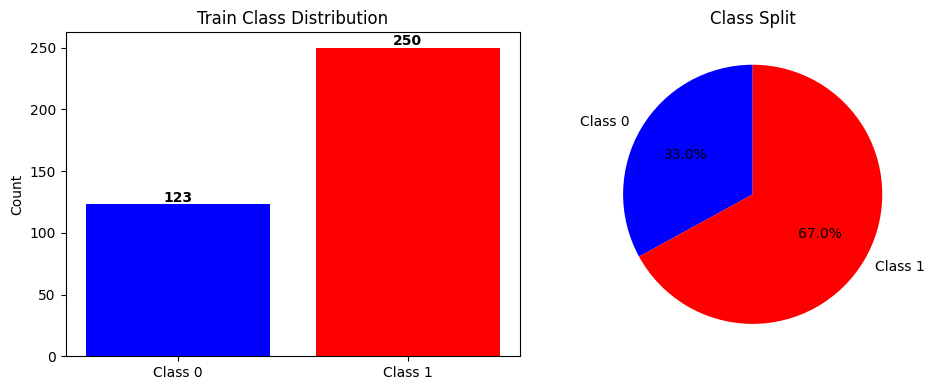

Class imbalance ratio: 1:2.03


In [13]:
counts = train_df['label'].value_counts().sort_index()

fig , axes = plt.subplots(1,2, figsize=(10, 4))

axes[0].bar(['Class 0', 'Class 1'], counts.values, color=['blue', 'red'])
axes[0].set_title('Train Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Class 0', 'Class 1'], autopct='%1.1f%%',
            colors=['blue', 'red'], startangle=90)
axes[1].set_title('Class Split')

plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: 1:{counts[1]/counts[0]:.2f}")


## sample some images


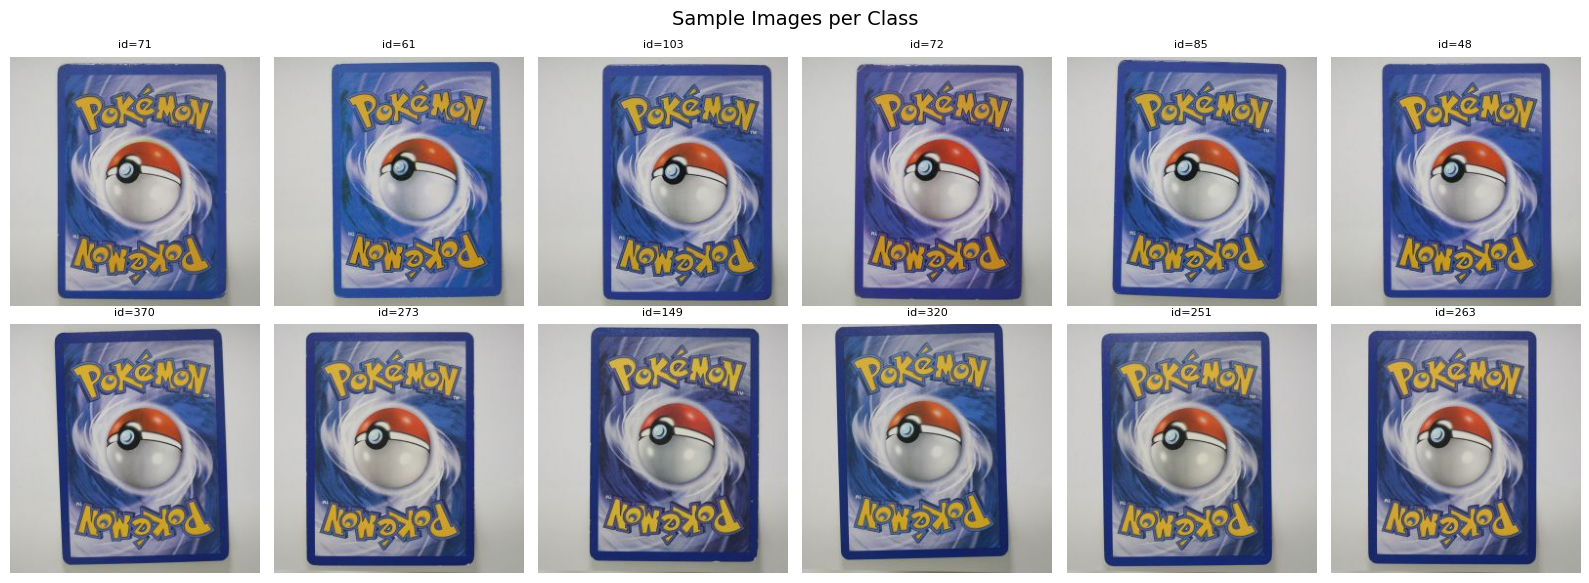

In [14]:
n = 6
fig, axes = plt.subplots(2, n, figsize=(16, 6))


for row, label in enumerate([0, 1]):
    sample_ids = train_df[train_df['label'] == label]['id'].sample(n, random_state=67)
    for col, img_id in enumerate(sample_ids):
        img = Image.open(f'train/{img_id}.JPG')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'id={img_id}', fontsize=8)
    axes[row, 0].set_ylabel(f'Class {label}', fontsize=12, fontweight='bold')


plt.suptitle('Sample Images per Class', fontsize=14)
plt.tight_layout()
plt.show()

## Pixel stats 

In [16]:
stats = {}
for label in [0, 1]:
    ids = train_df[train_df['label'] == label]['id']
    pixels = np.stack([np.array(Image.open(f'train/{i}.JPG')) for i in ids])
    stats[label] = {
        'mean_rgb': pixels.mean(axis=(0, 1, 2)),
        'std_rgb':  pixels.std(axis=(0, 1, 2)),
        'mean_brightness': pixels.mean(),
        'min': pixels.min(),
        'max': pixels.max(),
    }
    print(f"Class {label}:")
    print(f"\tMean RGB: {pixels.mean(axis=(0,1,2)).round(1)}")
    print(f"\tStd  RGB: {pixels.std(axis=(0,1,2)).round(1)}")
    print(f"\tBrightness avg: {pixels.mean():.1f}")
    print()

Class 0:
	Mean RGB: [139.2 140.7 152.6]
	Std  RGB: [62.5 56.1 46.4]
	Brightness avg: 144.2

Class 1:
	Mean RGB: [138.6 138.9 147.4]
	Std  RGB: [62.8 57.  47. ]
	Brightness avg: 141.6



pretty similar

## RGB Histogram per Class

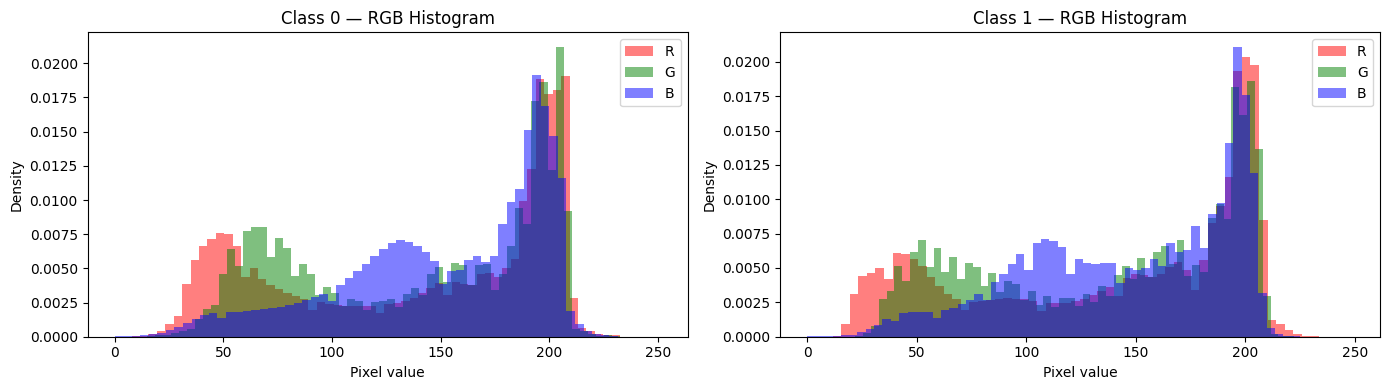

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['red', 'green', 'blue']
channel_names = ['R', 'G', 'B']

for label in [0, 1]:
    ids = train_df[train_df['label'] == label]['id']
    pixels = np.stack([np.array(Image.open(f'train/{i}.JPG')) for i in ids])
    for c, (color, name) in enumerate(zip(colors, channel_names)):
        axes[label].hist(pixels[:, :, :, c].flatten(), bins=64, alpha=0.5,
                         color=color, label=name, density=True)
    axes[label].set_title(f'Class {label} — RGB Histogram')
    axes[label].set_xlabel('Pixel value')
    axes[label].set_ylabel('Density')
    axes[label].legend()

plt.tight_layout()
plt.show()